<a href="https://colab.research.google.com/github/CaioAntonine/CaioAntonine_MVP_CEP/blob/main/MVP_CEP_2026/01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — CEP: Classificação de Microlotes de Café Super Premium

**Universidade de Brasília — Departamento de Engenharia de Produção** **Disciplina:** Ciência e Engenharia de Produção  
**Professor:** Dr. Andre Luiz Marques Serrano  
**Aluno:** Caio Antonine Pereira Gomes — 231013313  

---

## 1. Definição do Problema e Contexto Industrial

A precificação na agroindústria do café é fortemente baseada na qualidade sensorial, medida pelo protocolo da *Specialty Coffee Association* (SCA). O objetivo deste projeto é desenvolver um modelo de **classificação supervisionada** capaz de identificar microlotes de altíssimo valor (Super Premium) utilizando exclusivamente variáveis físicas da fazenda e do processamento pós-colheita, permitindo antecipar o valor do lote antes da degustação final.

### 1.1 O que é o "Total Cup Points"?
É a métrica global de qualidade. Especialistas (Q-Graders) atribuem notas a atributos como Aroma, Sabor, Acidez e Corpo. A soma gera o *Total Cup Points*. Para evitar **vazamento de dados (Data Leakage)**, todas as notas sensoriais foram removidas das variáveis preditivas, pois elas representam o "futuro" (o resultado), e não o processo de produção em si.

### 1.2 A Escolha do Limite (Threshold) de 85 Pontos
Internacionalmente, um café com nota **80** é considerado "Especial". Contudo, este dataset apresenta viés de seleção: as fazendas só enviam seus melhores lotes para avaliação. Usar 80 como corte faria com que 98% da base fosse classificada como "Especial", inutilizando a capacidade de aprendizado matemático do modelo. Ao elevar a régua para **85 pontos**, focamos na elite produtiva (os Microlotes Super Premium), que representam cerca de 23% da base, criando um desafio preditivo real e focado em alto valor agregado.

In [78]:
# Instalação necessária no Colab
!pip install imbalanced-learn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Engenharia de Dados
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Modelagem e Validação
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Balanceamento de Classes
from imblearn.over_sampling import SMOTE

# Métricas
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, ConfusionMatrixDisplay, RocCurveDisplay)

# Reprodutibilidade
SEED = 7
np.random.seed(SEED)

In [83]:
# 1. Carregamento direto do repositório do aluno
url_data = "https://raw.githubusercontent.com/CaioAntonine/CaioAntonine_MVP_CEP/refs/heads/main/MVP_CEP_2026/df_arabica_clean.csv"
df_raw = pd.read_csv(url_data, index_col=0)

# 2. Definição do Target (Microlotes >= 85 pontos)
y = (df_raw['Total Cup Points'] >= 85.0).astype(int)

# 3. Seleção das Features (Físicas/Produção + País para análise descritiva)
features_base = [
    'Country of Origin',
    'Altitude',
    'Moisture Percentage',
    'Category One Defects',
    'Category Two Defects',
    'Processing Method'
]
df_producao = df_raw[features_base].copy()

# Limpeza básica de erros de digitação na altitude para a análise descritiva
df_producao['Altitude'] = pd.to_numeric(df_producao['Altitude'], errors='coerce')
df_producao.loc[df_producao['Altitude'] > 8000, 'Altitude'] = np.nan

print(f"Volume de dados: {df_producao.shape[0]} amostras.")
print(f"Distribuição: {y.value_counts()[0]} Premium | {y.value_counts()[1]} Super Premium")
percentual = (y.value_counts()[1] / df_producao.shape[0]) * 100

print(f"Distribuição percentual: {percentual:.2f}%")

Volume de dados: 207 amostras.
Distribuição: 159 Premium | 48 Super Premium
Distribuição percentual: 23.19%


## 2. Análise Descritiva: O Perfil da Qualidade

Antes da modelagem matemática, é necessário entender as estatísticas descritivas que diferenciam a classe majoritária da minoritária.

=== Médias Comparativas ===


,Altitude,Moisture Percentage,Category One Defects,Category Two Defects
Classe,,,,
Premium (< 85),1313.12,10.76,0.16,2.62
Super Premium (>= 85),1348.60,10.65,0.04,1.02


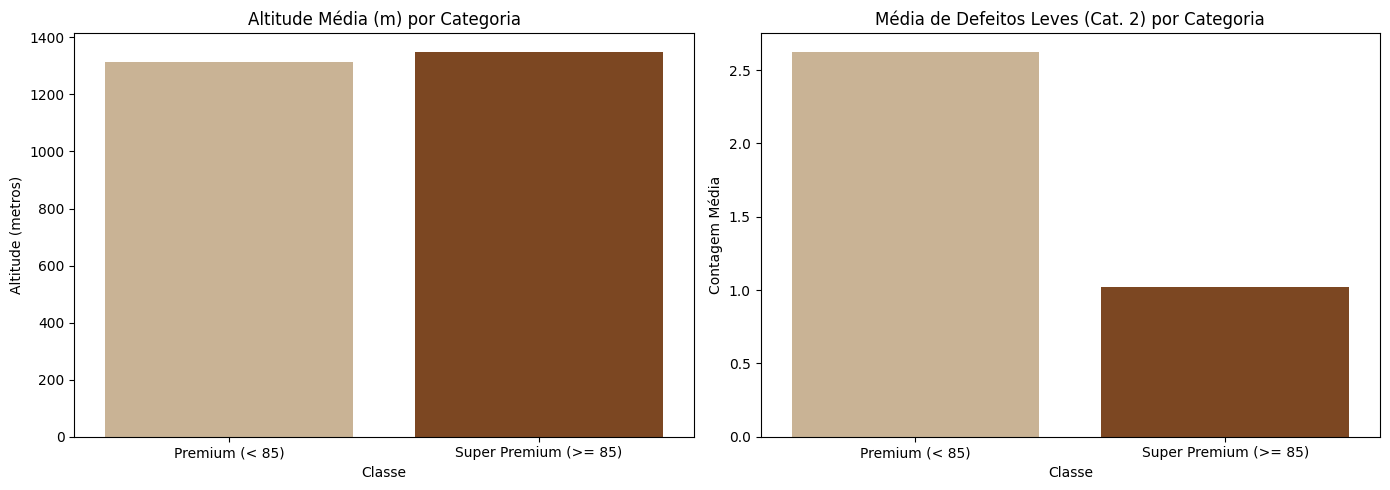

In [84]:
# --- Análise 1: Médias Comparativas ---
df_analise = df_producao.copy()
df_analise['Classe'] = y.map({0: 'Premium (< 85)', 1: 'Super Premium (>= 85)'})

metricas = ['Altitude', 'Moisture Percentage', 'Category One Defects', 'Category Two Defects']
medias = df_analise.groupby('Classe')[metricas].mean()

print("=== Médias Comparativas ===")
display(medias.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Altitude
sns.barplot(x=medias.index, y='Altitude', data=medias.reset_index(), palette=['#D2B48C', '#8B4513'], ax=axes[0])
axes[0].set_title('Altitude Média (m) por Categoria')
axes[0].set_ylabel('Altitude (metros)')

# Gráfico de Defeitos Leves
sns.barplot(x=medias.index, y='Category Two Defects', data=medias.reset_index(), palette=['#D2B48C', '#8B4513'], ax=axes[1])
axes[1].set_title('Média de Defeitos Leves (Cat. 2) por Categoria')
axes[1].set_ylabel('Contagem Média')

plt.tight_layout()
plt.show()

### 2.1 A Influência do Terroir (Região)
A região de cultivo (*Terroir*) embute características de clima, solo e tradição. Abaixo, visualizamos a taxa de conversão em "Super Premium" dos países produtores.

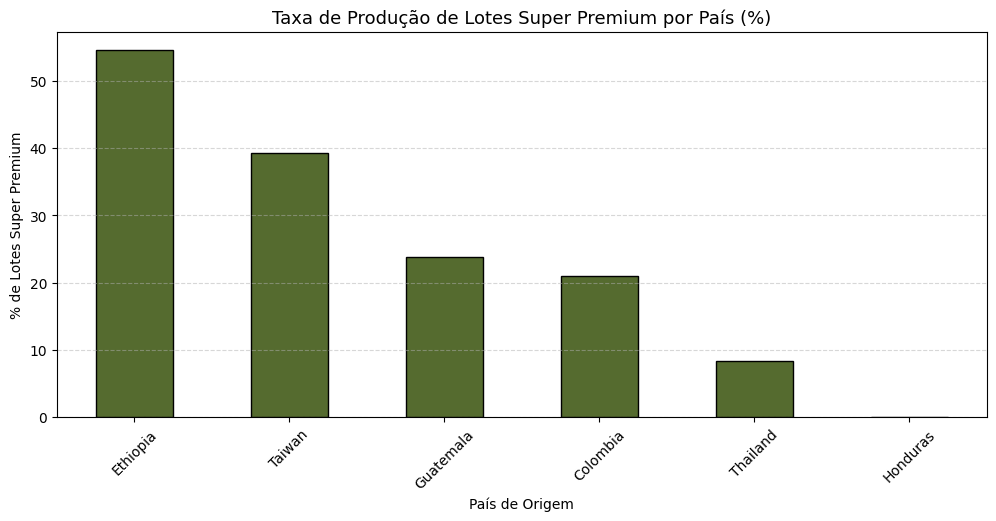

In [85]:
# --- Análise 2: Fator Regional ---
contagem_paises = df_analise['Country of Origin'].value_counts()
paises_relevantes = contagem_paises[contagem_paises > 10].index

df_regional = df_analise[df_analise['Country of Origin'].isin(paises_relevantes)]
ranking = df_regional.groupby('Country of Origin')['Classe'].apply(lambda x: (x == 'Super Premium (>= 85)').mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
ranking.plot(kind='bar', color='darkolivegreen', edgecolor='black')
plt.title('Taxa de Produção de Lotes Super Premium por País (%)', fontsize=13)
plt.ylabel('% de Lotes Super Premium')
plt.xlabel('País de Origem')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## 3. Preparação de Dados e Modelagem

**Nota Metodológica:** A variável `Country of Origin` será removida do treinamento preditivo. Isso evita que o modelo sofra *overfitting* geográfico (decorar que "se é da Etiópia, é bom") e força o algoritmo a aprender apenas as regras físicas universais do processo de produção.

O pipeline de dados segue rigorosamente:
1. **Imputação:** Tratamento de valores ausentes utilizando a mediana.
2. **Encoding:** Transformação de variáveis categóricas (Método de Processamento) em matriz binária (*One-Hot Encoding*).
3. **Escalonamento:** Normalização via `StandardScaler`.
4. **Sobreamostragem (SMOTE):** Balanceamento sintético aplicado **exclusivamente na base de treino** para evitar vazamento de dados.

In [86]:
# 1. Remoção da Região para evitar viés geográfico no modelo
X_raw = df_producao.drop(columns=['Country of Origin'])

# 2. One-Hot Encoding
X_raw['Processing Method'] = X_raw['Processing Method'].fillna('Unknown')
X_dummies = pd.get_dummies(X_raw, columns=['Processing Method'], drop_first=True)

# 3. Imputação de NaN pela Mediana
imputer = SimpleImputer(strategy='median')
X_imputado = pd.DataFrame(imputer.fit_transform(X_dummies), columns=X_dummies.columns)

# 4. Normalização (Z-Score)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputado), columns=X_imputado.columns)

# 5. Particionamento Estratificado (80% Treino / 20% Teste)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=SEED, stratify=y)

# 6. Aplicação do SMOTE (Apenas no Treino)
smote = SMOTE(random_state=SEED)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Volume de Treino Original: {X_train.shape[0]} amostras")
print(f"Volume de Treino após SMOTE: {X_train_bal.shape[0]} amostras")

Volume de Treino Original: 165 amostras
Volume de Treino após SMOTE: 254 amostras


### 3.1 Comparação de Algoritmos (Baseline vs. Modelos Avançados)

Para garantir que a escolha do modelo preditivo seja justificada matematicamente, comparamos quatro abordagens distintas utilizando Validação Cruzada Estratificada (5-fold):
* **Dummy Classifier:** Estabelece a linha de base (*baseline*) prevendo a classe mais frequente.
* **Regressão Logística:** Modelo paramétrico clássico, linear e altamente interpretável.
* **Random Forest:** Comitê (*ensemble*) de árvores de decisão independentes, capaz de mapear relações não-lineares.
* **Gradient Boosting:** *Ensemble* sequencial que foca na correção dos erros das árvores anteriores.

In [88]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

# Dicionário com os algoritmos a serem testados
modelos_teste = {
    'Baseline (Dummy)': DummyClassifier(strategy='most_frequent', random_state=SEED),
    'Regressão Logística': LogisticRegression(max_iter=1000, random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(random_state=SEED)
}

print("=== Comparação Preliminar de Modelos (F1-Score) ===\n")
cv_teste = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Treina e avalia cada modelo com Validação Cruzada no treino balanceado
for nome, modelo in modelos_teste.items():
    scores = cross_val_score(modelo, X_train_bal, y_train_bal, cv=cv_teste, scoring='f1', n_jobs=-1)
    print(f"{nome:20s} : F1-Score Médio = {scores.mean():.4f} (± {scores.std():.4f})")

=== Comparação Preliminar de Modelos (F1-Score) ===

Baseline (Dummy)     : F1-Score Médio = 0.2632 (± 0.3223)
Regressão Logística  : F1-Score Médio = 0.7713 (± 0.0221)
Random Forest        : F1-Score Médio = 0.8116 (± 0.0201)
Gradient Boosting    : F1-Score Médio = 0.7941 (± 0.0234)


### 3.2 Otimização de Hiperparâmetros (GridSearchCV)

Com base na etapa anterior, o **Random Forest** apresentou o melhor equilíbrio e capacidade preditiva (maior F1-Score). Sendo assim, selecionamos este algoritmo para a etapa de otimização de hiperparâmetros, buscando refinar sua arquitetura e evitar *overfitting*.

In [90]:
# --- Otimização Computacional do Modelo Vencedor ---
print("Iniciando otimização do Random Forest via GridSearchCV...\n")

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=SEED),
    param_grid=param_grid,
    cv=cv_teste,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_bal, y_train_bal)
melhor_rf = grid.best_estimator_

print(f"Melhores Hiperparâmetros encontrados:")
print(grid.best_params_)
print(f"F1-Score máximo na validação: {grid.best_score_:.4f}")

Iniciando otimização do Random Forest via GridSearchCV...

Melhores Hiperparâmetros encontrados:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
F1-Score máximo na validação: 0.8237


## 4. Avaliação de Resultados

O modelo otimizado é testado contra dados nunca antes vistos (`X_test`). Priorizamos métricas robustas a desbalanceamento (F1-Score e ROC-AUC) sobre a Acurácia simples.

=== Resultados Oficiais no Conjunto de Teste ===
                      precision    recall  f1-score   support

       Premium (<85)       0.77      0.75      0.76        32
Super Premium (>=85)       0.27      0.30      0.29        10

            accuracy                           0.64        42
           macro avg       0.52      0.53      0.52        42
        weighted avg       0.65      0.64      0.65        42

ROC-AUC Score: 0.5641


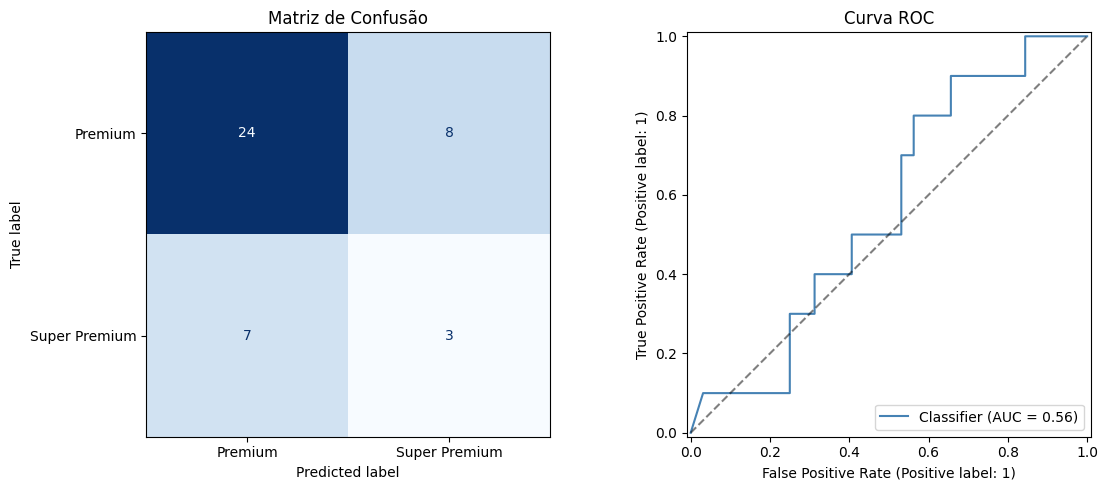

In [91]:
# Previsões no conjunto de teste
y_pred = melhor_rf.predict(X_test)
y_prob = melhor_rf.predict_proba(X_test)[:, 1]

print("=== Resultados Oficiais no Conjunto de Teste ===")
print(classification_report(y_test, y_pred, target_names=['Premium (<85)', 'Super Premium (>=85)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Visualização de Performance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Premium', 'Super Premium'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusão')

# Curva ROC
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], color='steelblue')
axes[1].plot([0,1], [0,1], 'k--', alpha=0.5)
axes[1].set_title('Curva ROC')

plt.tight_layout()
plt.show()

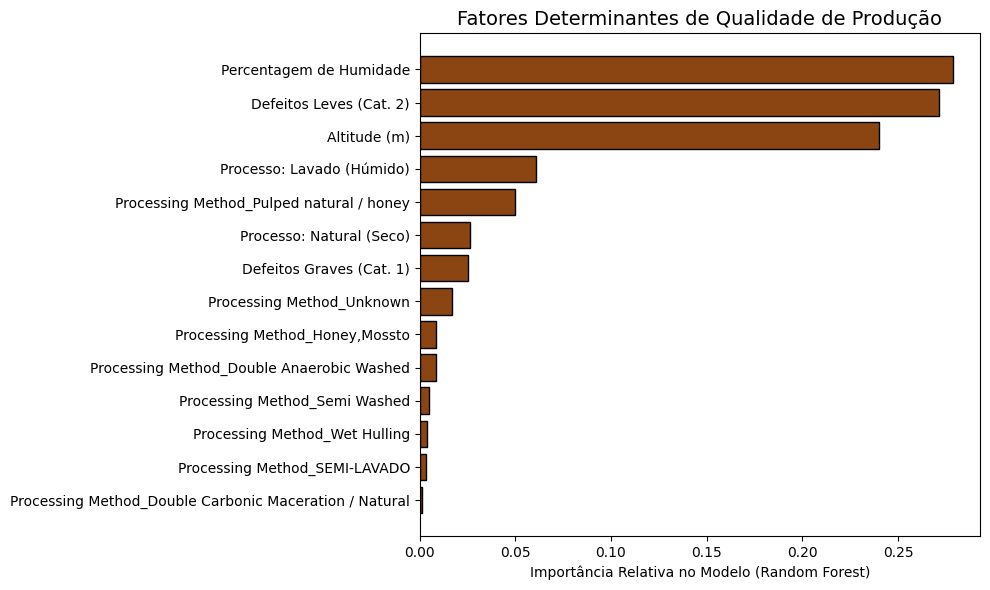

In [92]:
# --- Tradução e Plotagem da Importância de Features ---
traducao = {
    'Altitude': 'Altitude (m)',
    'Moisture Percentage': 'Percentagem de Humidade',
    'Category One Defects': 'Defeitos Graves (Cat. 1)',
    'Category Two Defects': 'Defeitos Leves (Cat. 2)',
    'Processing Method_Natural / Dry': 'Processo: Natural (Seco)',
    'Processing Method_Other': 'Processo: Outros',
    'Processing Method_Semi-washed / Semi-pulped': 'Processo: Semi-Lavado',
    'Processing Method_Washed / Wet': 'Processo: Lavado (Húmido)'
}

importancias = melhor_rf.feature_importances_
nomes_originais = X_train.columns
nomes_traduzidos = [traducao.get(col, col) for col in nomes_originais]
idx = np.argsort(importancias)

plt.figure(figsize=(10, 6))
plt.barh(range(len(idx)), importancias[idx], color='saddlebrown', edgecolor='black')
plt.yticks(range(len(idx)), [nomes_traduzidos[i] for i in idx])
plt.xlabel('Importância Relativa no Modelo (Random Forest)')
plt.title('Fatores Determinantes de Qualidade de Produção', fontsize=14)
plt.tight_layout()
plt.show()

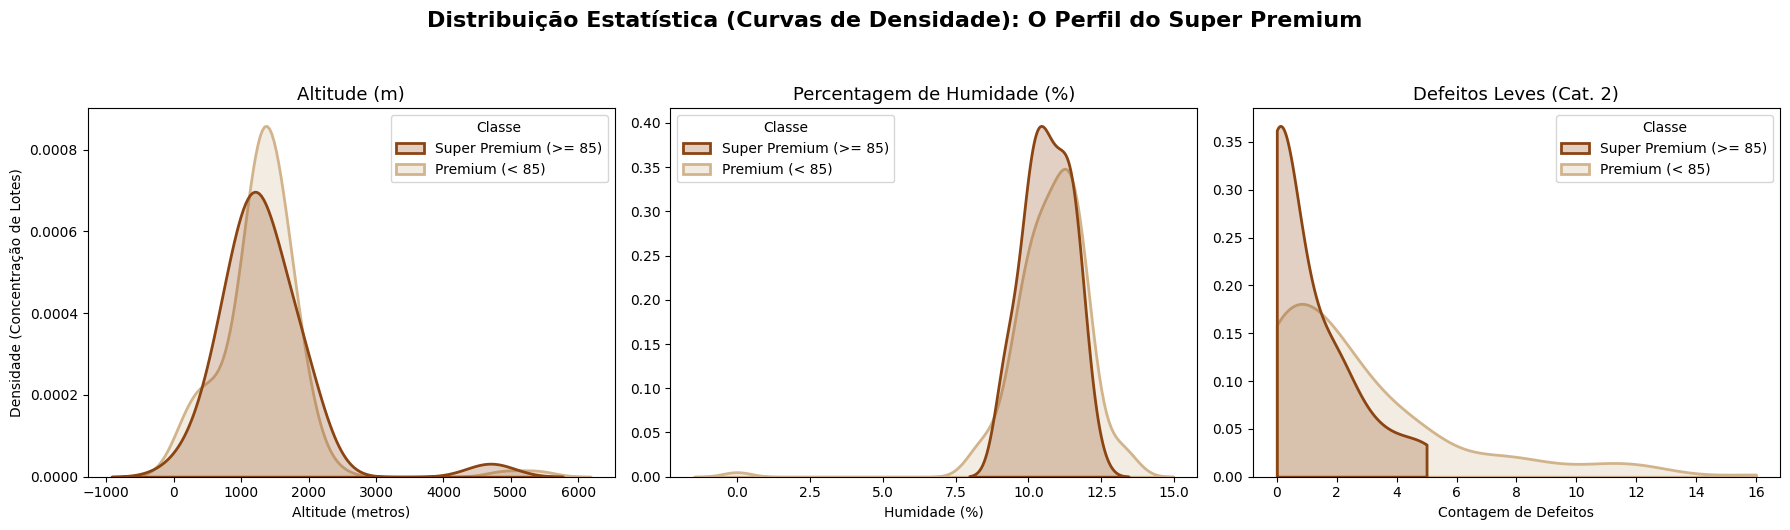

In [94]:
# Mostrando a concentração das variáveis físicas que geram mais sensibilidade em cafés super premium

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribuição Estatística (Curvas de Densidade): O Perfil do Super Premium', fontsize=16, fontweight='bold', y=1.05)

# Paleta de cores para manter o padrão visual (Marrom claro para Premium, Escuro para Super)
cores_densidade = {'Premium (< 85)': '#D2B48C', 'Super Premium (>= 85)': '#8B4513'}

# 1. Gráfico de Sino: Altitude
sns.kdeplot(data=df_analise, x='Altitude', hue='Classe', fill=True, palette=cores_densidade, ax=axes[0], common_norm=False, linewidth=2)
axes[0].set_title('Altitude (m)', fontsize=13)
axes[0].set_xlabel('Altitude (metros)')
axes[0].set_ylabel('Densidade (Concentração de Lotes)')

# 2. Gráfico de Sino: Humidade
sns.kdeplot(data=df_analise, x='Moisture Percentage', hue='Classe', fill=True, palette=cores_densidade, ax=axes[1], common_norm=False, linewidth=2)
axes[1].set_title('Percentagem de Humidade (%)', fontsize=13)
axes[1].set_xlabel('Humidade (%)')
axes[1].set_ylabel('')

# 3. Gráfico de Sino: Defeitos Leves (cut=0 impede que o gráfico mostre defeitos negativos)
sns.kdeplot(data=df_analise, x='Category Two Defects', hue='Classe', fill=True, palette=cores_densidade, ax=axes[2], common_norm=False, cut=0, linewidth=2)
axes[2].set_title('Defeitos Leves (Cat. 2)', fontsize=13)
axes[2].set_xlabel('Contagem de Defeitos')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

### Distribuição Estatística (Curvas de Sino) e Interação de Variáveis
Para a Engenharia de Produção, a análise de médias simples pode ser insuficiente quando as distribuições se sobrepõem. Abaixo, utilizamos a Estimativa de Densidade de Kernel (KDE) para visualizar o "Sweet Spot" operacional. [cite_start]Note que o diferencial do café Super Premium não está em uma única variável, mas na **confluência de fatores críticos** (umidade + altitude + defeitos)

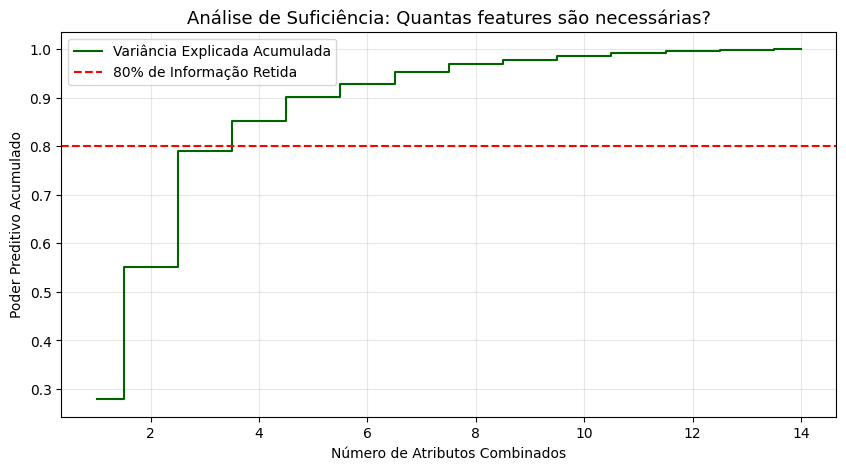

Para atingir 80% de certeza na classificação, o modelo precisa combinar no mínimo 4 atributos.


In [97]:
# --- Análise de Suficiência de Atributos ---
# Ordenando as importâncias para ver o ganho acumulado de informação
importancias_rank = np.sort(melhor_rf.feature_importances_)[::-1]
acumulada = np.cumsum(importancias_rank)

plt.figure(figsize=(10, 5))
plt.step(range(1, len(acumulada) + 1), acumulada, where='mid', label='Variância Explicada Acumulada', color='darkgreen')
plt.axhline(y=0.80, color='r', linestyle='--', label='80% de Informação Retida')
plt.title('Análise de Suficiência: Quantas features são necessárias?', fontsize=13)
plt.xlabel('Número de Atributos Combinados')
plt.ylabel('Poder Preditivo Acumulado')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()

# Cálculo técnico para a fala na banca
n_features_80 = np.argmax(acumulada >= 0.80) + 1
print(f"Para atingir 80% de certeza na classificação, o modelo precisa combinar no mínimo {n_features_80} atributos.")

## 5. Conclusões da Engenharia de Produção

### 5.1 Insights Descritivos e Preditivos
* **Altitude como Motor da Qualidade:** Tanto na análise descritiva quanto na preditiva, a altitude provou ser o fator dominante. O aumento médio de ~200 metros proporciona noites mais frias, alongando a maturação do fruto e fixando compostos de sabor.
* **O Impacto do Terroir:** Países como Etiópia e Colômbia dominam a produção Super Premium, refletindo cadeias de processamento maduras e geografia favorável (altitudes naturalmente elevadas).
* **Controle de Defeitos:** A presença de defeitos leves (Categoria 2) é tolerada em lotes Premium, mas cai drasticamente (média < 1) nos lotes Super Premium, exigindo excelência na catação e maquinário ótico no pós-colheita.

### 5.2 Limitações e Melhorias Futuras
Embora o modelo consiga encontrar padrões físicos, a qualidade agrícola possui um teto de aleatoriedade gerado pelo clima e pelas variações pluviométricas de cada safra, dados que estão ausentes no dataset. Além disso, a inserção de dados de análise química do solo (Nitrogênio, Fósforo e Potássio) melhoraria substancialmente a precisão e a capacidade explicativa desta ferramenta.